<a href="https://colab.research.google.com/github/Oskar1324/churn-prediction-project/blob/main/churn_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Churn Prediction – KfZ-Versicherung
In diesem Notebook entwickeln wir ein ML-Modell, das vorhersagt, ob ein Kunde
seine KfZ-Versicherung kündigt. Ziel ist es, gefährdete Kunden frühzeitig zu
erkennen, damit das Unternehmen proaktiv Maßnahmen ergreifen kann.

Die Prognosegüte wird anhand der Fläche unter der ROC-Kurve (AUC) gemessen.

# 1. Daten laden

In [42]:
# Colab: Datei hochladen
from google.colab import files

uploaded = files.upload()

Saving records.csv to records (1).csv


In [43]:
import pandas as pd


In [44]:
# Daten laden:

data = pd.read_csv('records.csv')

In [45]:
data.dtypes

,0
id,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
NumOfProducts,int64
HasCrCard,float64


In [46]:
data.describe()

,id,CustomerId,CreditScore,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary,Exited
count,164210.000000,1.642100e+05,164210.000000,164210.000000,164210.000000,164210.000000,164210.000000,164210.000000,164210.000000
mean,82928.500000,1.569201e+07,656.466275,38.129473,5.019840,1.554485,0.754016,112570.776646,0.211668
std,47403.488189,7.139650e+04,80.094156,8.868562,2.805613,0.547112,0.430670,50292.426883,0.408492
min,824.000000,1.556570e+07,350.000000,18.000000,0.000000,1.000000,0.000000,11.580000,0.000000
25%,41876.250000,1.563314e+07,597.000000,32.000000,3.000000,1.000000,1.000000,74593.840000,0.000000
50%,82928.500000,1.569016e+07,659.000000,37.000000,5.000000,2.000000,1.000000,117946.300000,0.000000
75%,123980.750000,1.575682e+07,710.000000,42.000000,7.000000,2.000000,1.000000,155126.037500,0.000000
max,165033.000000,1.581569e+07,850.000000,92.000000,10.000000,4.000000,1.000000,199992.480000,1.000000


# 1.1 Überblick zu den Daten
Bevor wir ein Modell trainieren, verschaffen wir uns einen Überblick
über die Daten mit visuellen Darstellungen.

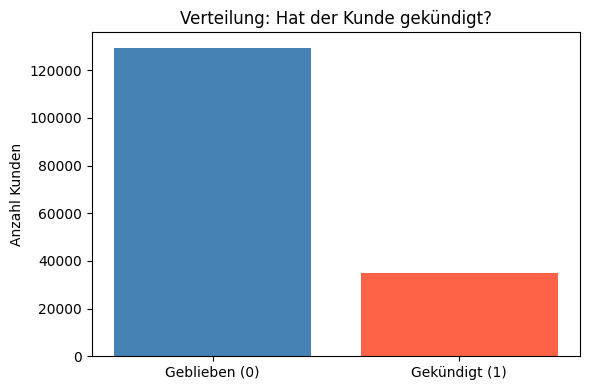

Anteil Churn: 21.2%


In [47]:
import matplotlib.pyplot as plt

# Verteilung des Targets: Wie viele Kunden haben gekündigt?
churn_counts = data["Exited"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Geblieben (0)", "Gekündigt (1)"], churn_counts.values,
        color=["steelblue", "tomato"])
plt.title("Verteilung: Hat der Kunde gekündigt?")
plt.ylabel("Anzahl Kunden")
plt.tight_layout()
plt.show()

print(f"Anteil Churn: {churn_counts[1] / len(data) * 100:.1f}%")

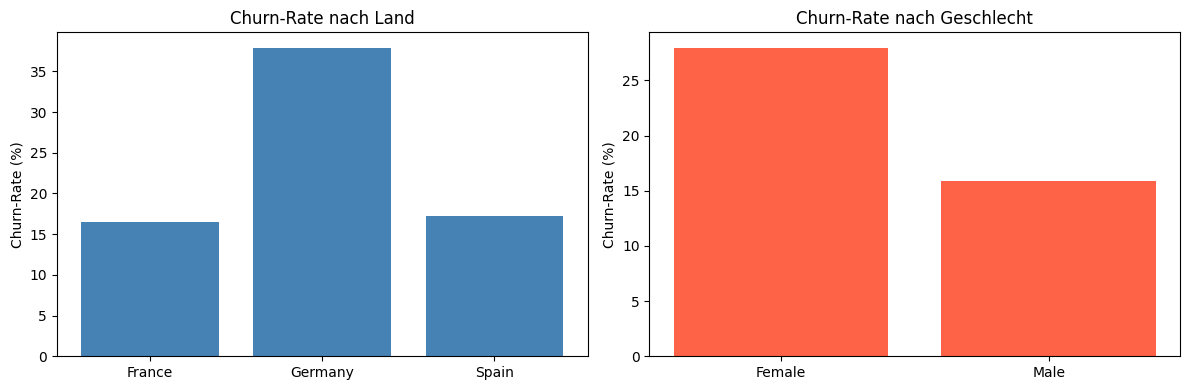

In [48]:
# Churn-Rate nach Geography und Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_geo = data.groupby("Geography")["Exited"].mean() * 100
axes[0].bar(churn_geo.index, churn_geo.values, color="steelblue")
axes[0].set_title("Churn-Rate nach Land")
axes[0].set_ylabel("Churn-Rate (%)")

churn_gender = data.groupby("Gender")["Exited"].mean() * 100
axes[1].bar(churn_gender.index, churn_gender.values, color="tomato")
axes[1].set_title("Churn-Rate nach Geschlecht")
axes[1].set_ylabel("Churn-Rate (%)")

plt.tight_layout()
plt.show()

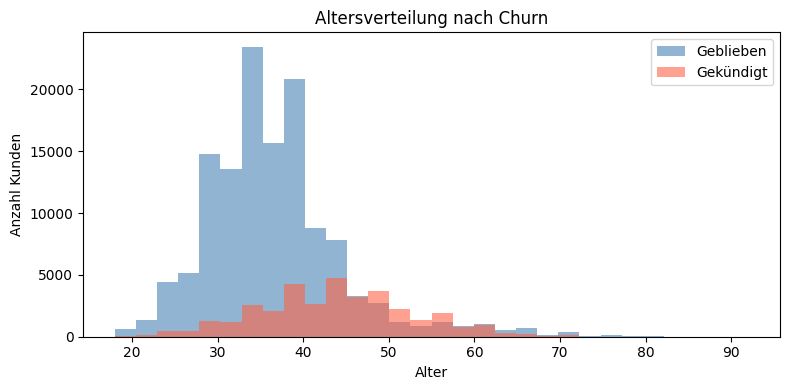

In [49]:
# Altersverteilung nach Churn
plt.figure(figsize=(8, 4))
plt.hist(data[data["Exited"]==0]["Age"], bins=30, alpha=0.6,
         label="Geblieben", color="steelblue")
plt.hist(data[data["Exited"]==1]["Age"], bins=30, alpha=0.6,
         label="Gekündigt", color="tomato")
plt.title("Altersverteilung nach Churn")
plt.xlabel("Alter")
plt.ylabel("Anzahl Kunden")
plt.legend()
plt.tight_layout()
plt.show()

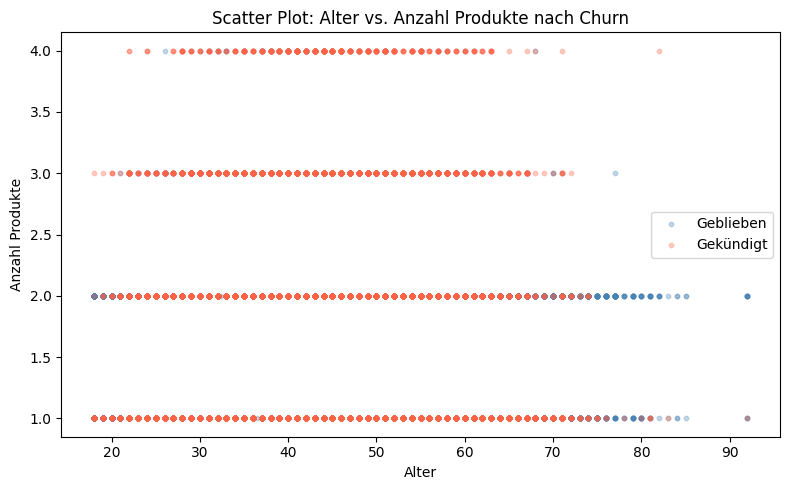

In [50]:
# Scatter Plot: Alter vs. Anzahl Produkte – eingefärbt nach Churn
plt.figure(figsize=(8, 5))
plt.scatter(
    data[data["Exited"]==0]["Age"],
    data[data["Exited"]==0]["NumOfProducts"],
    alpha=0.3, color="steelblue", label="Geblieben", s=10
)
plt.scatter(
    data[data["Exited"]==1]["Age"],
    data[data["Exited"]==1]["NumOfProducts"],
    alpha=0.3, color="tomato", label="Gekündigt", s=10
)
plt.xlabel("Alter")
plt.ylabel("Anzahl Produkte")
plt.title("Scatter Plot: Alter vs. Anzahl Produkte nach Churn")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Datensatz in Features und Target teilen

In [51]:
# Features: alles außer id, CustomerId, Surname und Exited
X = data.drop(columns=['id','CustomerId', 'Surname', 'Exited'])
X.head()



,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary
0,593,Germany,Male,48.0,10,1,1.0,178747.43
1,660,Germany,Female,36.0,2,1,1.0,110252.53
2,667,France,Female,36.0,6,2,0.0,120115.50
3,484,France,Male,33.0,0,1,0.0,42437.75
4,547,France,Female,50.0,1,1,1.0,135961.01


In [52]:
# Target, d.h. was soll prognostiziert werden: Exited(Ob der Kunde die Versicherung gekündigt hat (1 = ja, 0 = nein) )
y = data['Exited']
y.head()

,Exited
0,1
1,1
2,0
3,0
4,1


# 2.2 Datensatz in Trainings- und Testmenge aufteilen

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# X und y werden in Trainings- und Testmenge aufgeteilt, so dass die Testmenge 20% der vorhandenen Daten hat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [55]:
y_train.head()

,Exited
26553,0
149982,0
46327,0
121353,1
142844,0


In [56]:
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary
26553,573,France,Male,40.0,4,1,1.0,110454.46
149982,652,France,Male,30.0,2,2,0.0,77783.35
46327,817,France,Male,55.0,2,2,1.0,95941.55
121353,682,France,Female,47.0,10,1,1.0,66528.00
142844,703,Germany,Male,25.0,10,1,1.0,125870.74


# 2.3 Modell auswählen
Wir testen drei Modelle mit Standardeinstellungen und wählen
dasjenige mit dem höchsten AUC-Wert als finales Modell.

In [57]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import pandas as pd

# Datenaufbereitung
X_train_encoded = pd.get_dummies(X_train.copy(), columns=['Geography', 'Gender'], drop_first=True)
X_test_encoded  = pd.get_dummies(X_test.copy(),  columns=['Geography', 'Gender'], drop_first=True)
X_test_encoded  = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Skalierung für Logistische Regression
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled  = scaler.transform(X_test_encoded)

In [58]:
# Modell 1: Logistische Regression (Standardeinstellungen)
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
auc_lr = metrics.roc_auc_score(y_test, model_lr.predict_proba(X_test_scaled)[:, 1])
print(f"AUC Logistische Regression: {auc_lr:.4f}")

AUC Logistische Regression: 0.7925


In [59]:
# Modell 2: Random Forest (Standardeinstellungen)
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_encoded, y_train)
auc_rf = metrics.roc_auc_score(y_test, model_rf.predict_proba(X_test_encoded)[:, 1])
print(f"AUC Random Forest:          {auc_rf:.4f}")

AUC Random Forest:          0.8432


In [60]:
# Modell 3: Gradient Boosting (Standardeinstellungen)
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train_encoded, y_train)
auc_gb = metrics.roc_auc_score(y_test, model_gb.predict_proba(X_test_encoded)[:, 1])
print(f"AUC Gradient Boosting:      {auc_gb:.4f}")

AUC Gradient Boosting:      0.8657


In [61]:
# Vergleichstabelle
vergleich = pd.DataFrame({
    "Modell": ["Logistische Regression", "Random Forest", "Gradient Boosting"],
    "AUC":    [round(auc_lr, 4), round(auc_rf, 4), round(auc_gb, 4)]
})
vergleich.sort_values("AUC", ascending=False).reset_index(drop=True)

,Modell,AUC
0,Gradient Boosting,0.8657
1,Random Forest,0.8432
2,Logistische Regression,0.7925


Gradient Boosting erreicht den höchsten AUC-Wert und wird daher
für die Parameteroptimierung verwendet.

In [62]:
# Bestes Modell übernehmen
model = model_gb

# 2.4 Modell trainieren

Das Gradient Boosting Verfahren versucht nun einen Zusammenhang zwischen den
Features und dem Target zu lernen. Fehlklassifikation bedeutet hier: Das Modell
sagt vorher, dass ein Kunde kündigt – in Wirklichkeit bleibt er aber.

In [63]:
import pandas as pd

# Convert categorical features to numerical using one-hot encoding
# The .copy() is important to avoid SettingWithCopyWarning
X_train_encoded = pd.get_dummies(X_train.copy(), columns=['Geography', 'Gender'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test.copy(), columns=['Geography', 'Gender'], drop_first=True)

# Align columns - crucial step to ensure both dataframes have the same columns in the same order
# Get all columns from X_train_encoded
train_cols = X_train_encoded.columns

# Reindex X_test_encoded to match the columns of X_train_encoded, filling missing columns with 0
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)

model.fit(X_train_encoded, y_train)

GradientBoostingClassifier(random_state=42)

# 2.5 Modell anwenden

Das Gradient Boosting Verfahren erhält die Testdaten X_test, d.h. die Kundendaten
mit den relevanten Merkmalen, und wendet die gelernten Zusammenhänge zur Prognose
des Targets an – also ob ein Kunde seine KfZ-Versicherung kündigt (1) oder nicht (0).

In [64]:
X_test.head()

,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary
139734,627,Spain,Female,39.0,9,2,1.0,56875.62
75939,682,France,Male,33.0,1,2,1.0,174094.24
149600,712,Germany,Male,39.0,1,2,1.0,65864.40
68641,506,Germany,Male,29.0,0,2,1.0,166520.96
151910,611,France,Male,41.0,9,2,0.0,128600.49


In [65]:
y_pred = model.predict(X_test_encoded)

In [66]:
y_pred[:5]

array([0, 0, 0, 0, 0])

In [67]:
y_test.values[:5]

array([1, 0, 0, 0, 0])

In [68]:
pd.DataFrame({"Vorhersage":pd.Series(y_pred), "Beobachtung":pd.Series(y_test.values)},).head(10)

,Vorhersage,Beobachtung
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


# 2.6 Modell evaluieren
Die Modellbewertung erfolgt bei der Klassifikation regelmäßg nach dem Kriterium der "Accuracy" (andere kommen aber auch zum Einsatz). Die Accuracy setzt die Anzahl der korrekten Klassifikation in das Verhältnis zur Anzahl aller Beobachtungen. Dementsprechend stellt sie den Anteil der korrekten Klassifikationen dar.

In [69]:
from sklearn import metrics
import matplotlib.pyplot as plt

In [70]:
metrics.accuracy_score(y_test, y_pred) * 100

85.13488825284696

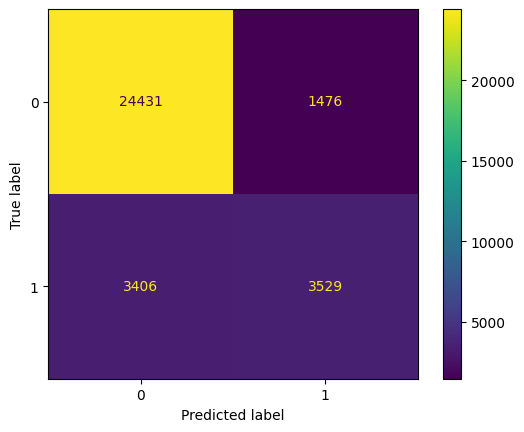

In [71]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = metrics.ConfusionMatrixDisplay(conf_matrix, display_labels=model.classes_)
disp.plot()
plt.show()

In [72]:
from sklearn.inspection import permutation_importance
import numpy as np

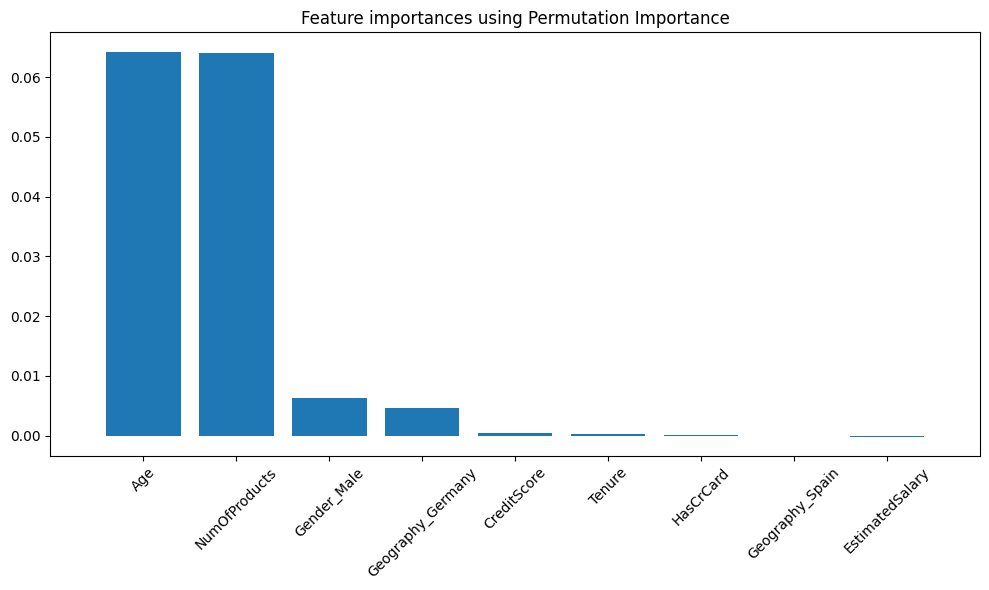

In [73]:
results = permutation_importance(model, X_test_encoded, y_test, n_repeats=10, random_state=42)
# Get the mean importance of each feature
importances = results.importances_mean

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature importances using Permutation Importance")
plt.bar(range(X_test_encoded.shape[1]), importances[indices], align="center")
plt.xticks(range(X_test_encoded.shape[1]), X_test_encoded.columns[indices], rotation=45)
plt.xlim([-1, X_test_encoded.shape[1]])
plt.tight_layout()
plt.show()

# 3 ROC-Kurve erstellen

In [74]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

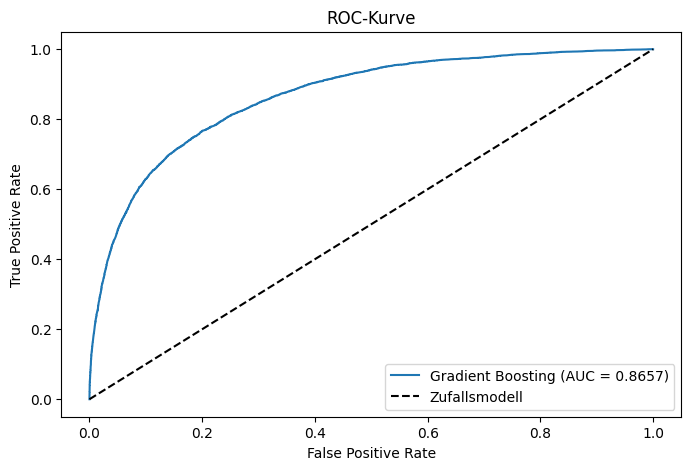

In [75]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]
auc = metrics.roc_auc_score(y_test, y_prob)

# ROC-Kurve plotten
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Zufallsmodell")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve")
plt.legend()
plt.show()

In [76]:
# AUC berechnen – dafür brauchen wir Wahrscheinlichkeiten, nicht nur 0/1
y_prob = model.predict_proba(X_test_encoded)[:, 1]

auc = metrics.roc_auc_score(y_test, y_prob)
print(f"AUC-Wert: {auc * 100:.2f}%")

AUC-Wert: 86.57%


# 3.1 Parameteroptimierung
Um den AUC-Wert weiter zu maximieren, optimieren wir die Hyperparameter
des Modells mit GridSearchCV. Diese Methode testet systematisch verschiedene
Parameterkombinationen und wählt die beste anhand der AUC aus.

In [77]:
from sklearn.model_selection import GridSearchCV

# Parameterkombinationen die getestet werden sollen
param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [3, 5],
    "learning_rate": [0.05, 0.1]
}

# GridSearch mit AUC als Gütekriterium
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring="roc_auc",   # ← optimiert direkt auf AUC!
    cv=3                 # 3-fache Kreuzvalidierung
)

grid_search.fit(X_train_encoded, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [78]:
# Beste Parameter und bester AUC-Wert
print("Beste Parameter:", grid_search.best_params_)
print("Bester AUC (Training):", grid_search.best_score_.round(4))

Beste Parameter: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Bester AUC (Training): 0.8644


In [79]:
# Optimiertes Modell auf Testdaten evaluieren
best_model = grid_search.best_estimator_

y_prob_opt = best_model.predict_proba(X_test_encoded)[:, 1]
auc_opt    = metrics.roc_auc_score(y_test, y_prob_opt)

print(f"AUC vor Optimierung:  {auc:.4f}")
print(f"AUC nach Optimierung: {auc_opt:.4f}")

AUC vor Optimierung:  0.8657
AUC nach Optimierung: 0.8661


# 3.2 ROC-Kurve mit optimiertem Modell

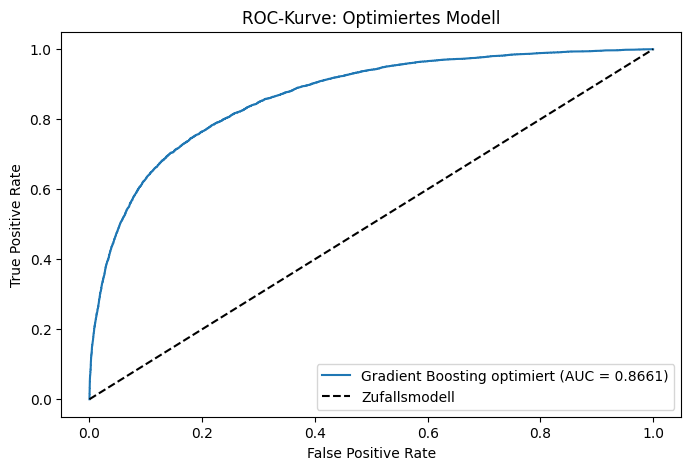

In [80]:
# ROC-Kurve mit optimiertem Modell
y_prob_opt = best_model.predict_proba(X_test_encoded)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob_opt)

auc_opt = metrics.roc_auc_score(y_test, y_prob_opt)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting optimiert (AUC = {auc_opt:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Zufallsmodell")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve: Optimiertes Modell")
plt.legend()
plt.show()

# 3.3 Modell mit Top 4 Features
Wir testen ob das Modell bereits mit den 4 wichtigsten Features
(Age, NumOfProducts, Geography, Gender) einen ähnlichen AUC erreicht.
Wenn ja, sind die anderen Features überflüssig.

In [81]:
# Nur die 4 wichtigsten Features verwenden
top4_features = ["Age", "NumOfProducts", "Geography", "Gender"]

X_train_top4 = X_train[top4_features].copy()
X_test_top4  = X_test[top4_features].copy()

# Encoding
X_train_top4 = pd.get_dummies(X_train_top4, columns=["Geography", "Gender"], drop_first=True)
X_test_top4  = pd.get_dummies(X_test_top4,  columns=["Geography", "Gender"], drop_first=True)
X_test_top4  = X_test_top4.reindex(columns=X_train_top4.columns, fill_value=0)

# Modell mit Top 4 trainieren
model_top4 = GradientBoostingClassifier(random_state=42)
model_top4.fit(X_train_top4, y_train)

y_prob_top4 = model_top4.predict_proba(X_test_top4)[:, 1]
auc_top4    = metrics.roc_auc_score(y_test, y_prob_top4)

print(f"AUC alle Features:    {auc_opt:.4f}")
print(f"AUC Top 4 Features:   {auc_top4:.4f}")

AUC alle Features:    0.8661
AUC Top 4 Features:   0.8645


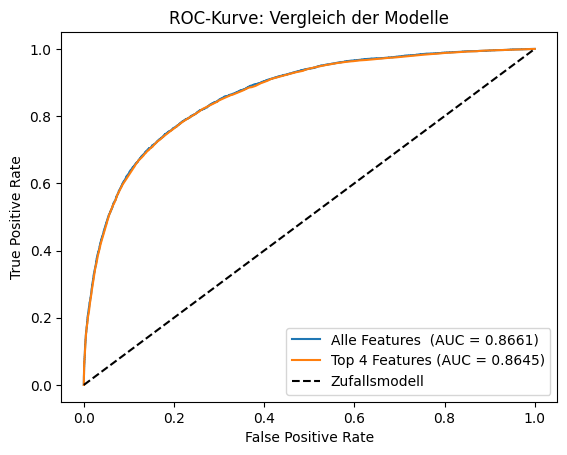

In [82]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Ensure fpr_opt, tpr_opt are defined from the optimized model
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_prob_opt)

# Ensure fpr_top4, tpr_top4 are defined from the top 4 features model
fpr_top4, tpr_top4, _ = roc_curve(y_test, y_prob_top4)

# Alle Features vs. Top 4 → zeigt ob man Features weglassen kann
plt.plot(fpr_opt,  tpr_opt,  label=f"Alle Features  (AUC = {auc_opt:.4f})")
plt.plot(fpr_top4, tpr_top4, label=f"Top 4 Features (AUC = {auc_top4:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Zufallsmodell') # Adding a random model for comparison
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve: Vergleich der Modelle')
plt.legend()
plt.show()

# 4. Prognose: Kunden mit höchster Kündigungswahrscheinlichkeit

Das Modell gibt für jeden Kunden eine individuelle Kündigungswahrscheinlichkeit aus.
Die folgende Tabelle zeigt die 10 Kunden mit dem höchsten Kündigungsrisiko –
genau diese Kunden sollte die Versicherung zuerst kontaktieren.

In [83]:
kunden_ids = data.loc[X_test.index, "CustomerId"].values

y_prob_final = model.predict_proba(X_test_encoded)[:, 1]

ergebnis = pd.DataFrame({
    "CustomerId": kunden_ids,
    "Kuendigungswahrscheinlichkeit (%)": (y_prob_final * 100).round(1),
    "Prognose": ["Kündigt" if p >= 0.5 else "Bleibt" for p in y_prob_final]
})

ergebnis.sort_values("Kuendigungswahrscheinlichkeit (%)", ascending=False).head(10)

,CustomerId,Kuendigungswahrscheinlichkeit (%),Prognose
10166,15625905,97.1,Kündigt
24920,15764047,97.0,Kündigt
21199,15766563,97.0,Kündigt
31458,15691825,96.9,Kündigt
19451,15752342,96.8,Kündigt
12760,15594917,96.7,Kündigt
22774,15594878,96.7,Kündigt
6727,15672481,96.6,Kündigt
26097,15756625,96.5,Kündigt
17890,15605918,96.5,Kündigt
